In [3]:
import shap
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Loading the best model (Gradient Boosting)
model = joblib.load('../models/best_model.pkl')

# Loading the test data
X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').values.ravel()

In [4]:
# Building a TreeExplainer for fast, exact SHAP values
explainer = shap.TreeExplainer(model)

# Computing SHAP values on the test set
shap_values = explainer(X_test)


In [8]:
explainer

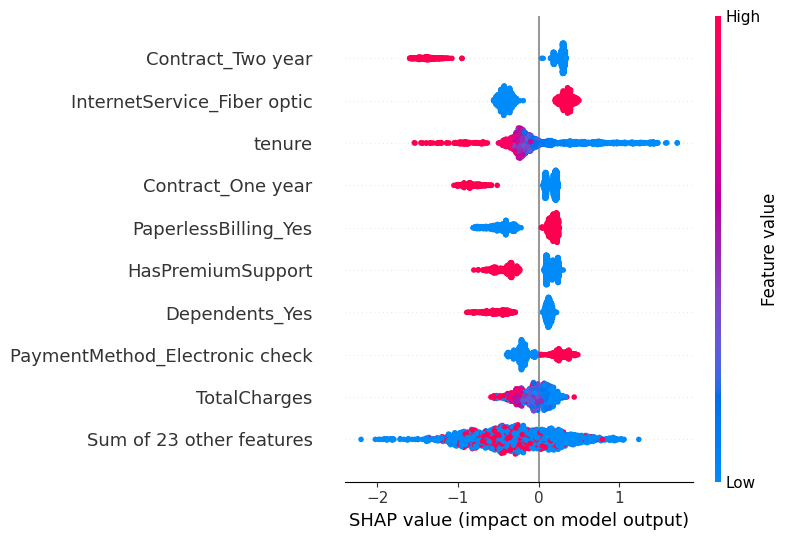

In [5]:
# Generating the SHAP beeswarm summary plot
shap.plots.beeswarm(shap_values, show=False)
plt.tight_layout()
plt.savefig('../reports/figures/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Calculating mean absolute SHAP value per feature
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
feature_importance = pd.DataFrame({
    'feature': X_test.columns,
    'importance': mean_abs_shap
}).sort_values('importance', ascending=False)

# Taking top 5 features
top_5 = feature_importance.head(5).copy()

# Mapping technical feature names to business-friendly labels
label_map = {
    'Contract_Month-to-month': 'Month-to-month contract',
    'tenure': 'Tenure (months as customer)',
    'MonthlyCharges': 'High monthly charges',
    'HasPremiumSupport': 'No premium support',
    'InternetService_Fiber optic': 'Fiber optic internet'
}
top_5['label'] = top_5['feature'].map(label_map).fillna(top_5['feature'])

In [10]:
#print(mean_abs_shap)
#print(feature_importance)
#print(top_5)

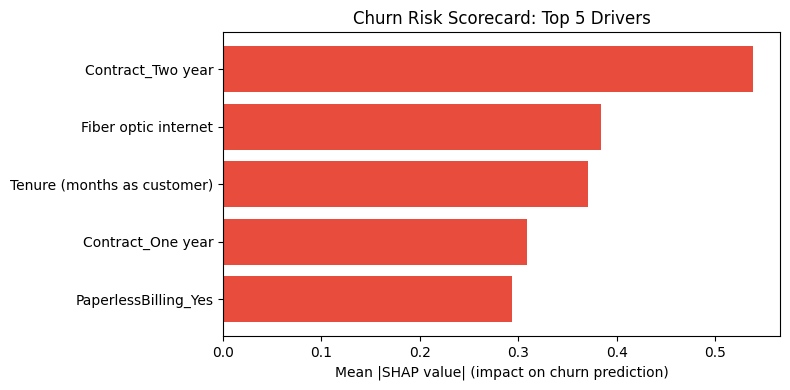

In [12]:
# Creating the Churn Risk Scorecard
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(top_5['label'], top_5['importance'], color='#e74c3c')
ax.set_xlabel('Mean |SHAP value| (impact on churn prediction)')
ax.set_title('Churn Risk Scorecard: Top 5 Drivers')
ax.invert_yaxis()  # Highest importance at the top
plt.tight_layout()
plt.savefig('../reports/figures/churn_risk_scorecard.png', dpi=150, bbox_inches='tight')
plt.show()